# Amazon ML Challenge 2026: Business Entity Resolution (v3)
**Team:** The Epoch Warriors: Rajveer Gupta, Manas Tiwari, Hrutuparna Bedekar, Utikshan Upman

For every Source-1 (S1) business, find all Source-2/3 records of the same real-world business.
The metric is per-S1 F0.5 (precision-weighted), macro-averaged over all S1 including singletons.

**Submission in this package:** Stage A (Test 3 + Qwen score on the wide band 0.02-0.98).
Test-like validation macro F0.5 **0.99158**; public leaderboard **not uploaded when this notebook was built**.

Contents:
1. Setup
2. Exploratory data analysis
3. Preprocessing (normalisation) and the ghost-S1 split
4. Candidate generation
5. Feature representation
6. Models and results
7. Why we abstain on address-less, same-name records
8. Pipeline code (full v3 source)
9. Reproduce
10. Official validator on the submitted files

Sections 2, 3, 5 (partly) and 10 run live on the raw data.
Model results in 4–7 are the values logged by the GPU runs (Lightning AI A100 / H100).

## 1. Setup

In [1]:
import os, sys, re, json, subprocess, ast, time, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
PROJECT = Path.cwd()
DATA = PROJECT / 'data'
os.environ.setdefault('ER_ROOT', str(PROJECT / 'nb_work'))     # keeps the package's cache folders out of the system root
sys.path.insert(0, str(PROJECT))
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from rapidfuzz import process, fuzz
pl.Config.set_tbl_rows(30); pl.Config.set_tbl_width_chars(160); pl.Config.set_fmt_str_lengths(70)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3, 'axes.spines.top': False, 'axes.spines.right': False})
C1, C2, C3 = '#2a6f97', '#e76f51', '#8ab17d'
rd = lambda p: pl.read_csv(p, separator='\t', quote_char=None, infer_schema=False)
MATCHING = Path(r'submissions/stageA/matching_results.tsv'); CANDIDATE = Path(r'submissions/stageA/candidate_pairs.tsv')
t0 = time.time()
tr1, tr2, tr3 = [rd(DATA / 'train' / f'train_source{s}.tsv') for s in '123']
te1, te2, te3 = [rd(DATA / 'test' / f'test_source{s}.tsv') for s in '123']
gt = rd(DATA / 'train' / 'train_ground_truth.tsv')
print(f'loaded in {time.time() - t0:.0f}s')

loaded in 4s


## 2. Exploratory data analysis
### 2.1 Files, sources and countries

shape: (6, 5)
┌───────┬────────┬─────────┬─────────┬────────┐
│ split ┆ source ┆ India   ┆ US      ┆ France │
│ ---   ┆ ---    ┆ ---     ┆ ---     ┆ ---    │
│ str   ┆ str    ┆ i64     ┆ i64     ┆ i64    │
╞═══════╪════════╪═════════╪═════════╪════════╡
│ train ┆ S1     ┆ 883188  ┆ 1323633 ┆ null   │
│ train ┆ S2     ┆ 2017799 ┆ 3016817 ┆ null   │
│ train ┆ S3     ┆ 2115547 ┆ 3170056 ┆ null   │
│ test  ┆ S1     ┆ 809986  ┆ 663106  ┆ 259452 │
│ test  ┆ S2     ┆ 2312565 ┆ 1871330 ┆ 703378 │
│ test  ┆ S3     ┆ 2405000 ┆ 1945701 ┆ 731615 │
└───────┴────────┴─────────┴─────────┴────────┘


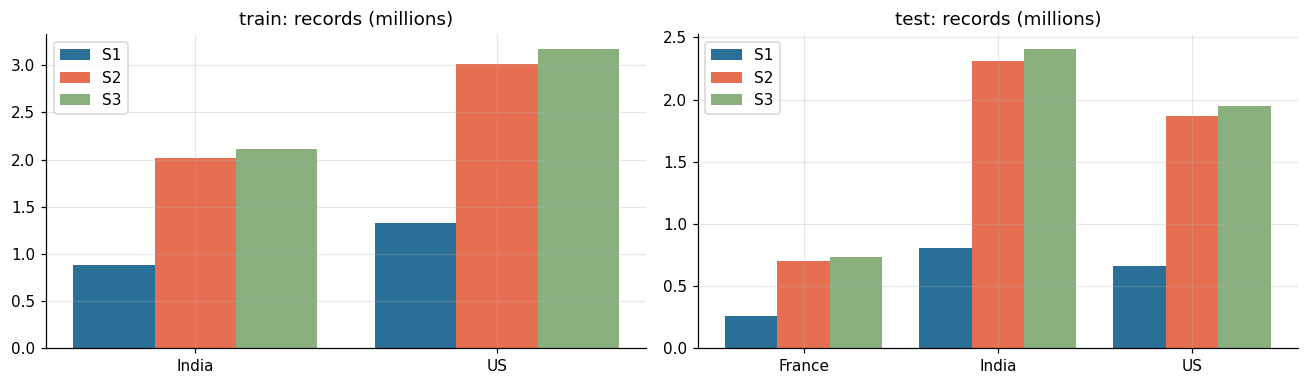

France appears only in test: country must be treated as an open set.


In [2]:
rows = []
for split, tabs in [('train', (tr1, tr2, tr3)), ('test', (te1, te2, te3))]:
    for s, t in zip('123', tabs):
        for c, n in t.group_by('country').len().sort('country').iter_rows():
            rows.append((split, f'S{s}', c, n))
counts = pl.DataFrame(rows, schema=['split', 'source', 'country', 'records'], orient='row')
print(counts.pivot(on='country', index=['split', 'source'], values='records'))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for a, split in zip(ax, ['train', 'test']):
    d = counts.filter(pl.col('split') == split).pivot(on='source', index='country', values='records').sort('country')
    x = np.arange(d.height)
    for k, (s, col) in enumerate(zip(['S1', 'S2', 'S3'], [C1, C2, C3])):
        a.bar(x + (k - 1) * 0.27, d[s].to_numpy() / 1e6, 0.27, label=s, color=col)
    a.set_xticks(x, d['country'].to_list()); a.set_title(f'{split}: records (millions)'); a.legend()
plt.tight_layout(); plt.show()
print('France appears only in test: country must be treated as an open set.')

### 2.2 Ground truth: group sizes, singletons, sources

train S1: 2206821 | positive pairs: 7638365 | singletons: 5.58 % | mean matches per S1: 3.46 (S2 1.67, S3 1.79), max 11


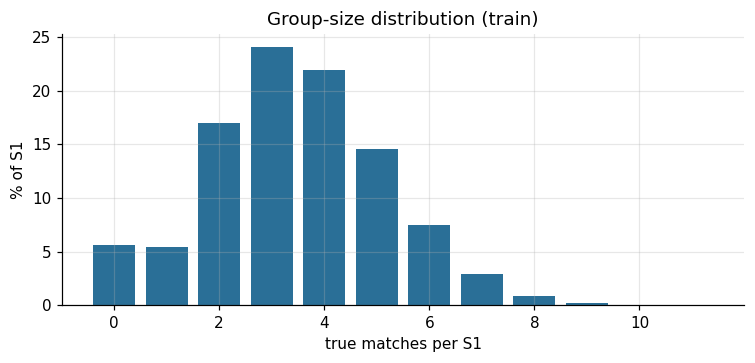

each S2/S3 record belongs to at most one S1: True


In [3]:
g = gt.with_columns(ids=pl.col('matched_entity_ids').fill_null('').str.split(',').list.eval(pl.element().filter(pl.element() != '')))
g = g.with_columns(n=pl.col('ids').list.len(), n2=pl.col('ids').list.eval(pl.element().str.starts_with('S2-')).list.sum(),
                   n3=pl.col('ids').list.eval(pl.element().str.starts_with('S3-')).list.sum())
print('train S1:', g.height, '| positive pairs:', int(g['n'].sum()), '| singletons: %.2f %%' % (100 * (g['n'] == 0).mean()),
      '| mean matches per S1: %.2f (S2 %.2f, S3 %.2f), max %d' % (g['n'].mean(), g['n2'].mean(), g['n3'].mean(), g['n'].max()))
vc = g.group_by('n').len().sort('n')
fig, ax = plt.subplots(figsize=(8, 3.2)); ax.bar(vc['n'].to_numpy(), vc['len'].to_numpy() / g.height * 100, color=C1)
ax.set_xlabel('true matches per S1'); ax.set_ylabel('% of S1'); ax.set_title('Group-size distribution (train)'); plt.show()
all_ids = g.select(pl.col('ids').explode()).drop_nulls()['ids']
print('each S2/S3 record belongs to at most one S1:', all_ids.n_unique() == all_ids.len())

### 2.3 Train/test shift: distractor records

In [4]:
def per_s1(t1, t2, t3):
    r = pl.concat([t2, t3]).group_by('country').len('records'); s = t1.group_by('country').len('S1')
    return s.join(r, on='country').with_columns(records_per_S1=(pl.col('records') / pl.col('S1')).round(3)).sort('country')
tr = per_s1(tr1, tr2, tr3); te = per_s1(te1, te2, te3)
matched = int(g['n'].sum()); total = tr['records'].sum()
print('train records per S1:'); print(tr); print('test records per S1:'); print(te)
print(f'train distractor share (records matching no S1): {1 - matched / total:.1%}')
print(f'test distractor share if true matches per S1 stay at {g["n"].mean():.2f} (estimated from exact-name hit rates): '
      f'{1 - g["n"].mean() * te["S1"].sum() / te["records"].sum():.1%}')
print('-> every model and threshold is fitted on a "ghost-S1" train with the test-like 41 % distractor rate (section 3).')

train records per S1:
shape: (2, 4)
┌─────────┬─────────┬─────────┬────────────────┐
│ country ┆ S1      ┆ records ┆ records_per_S1 │
│ ---     ┆ ---     ┆ ---     ┆ ---            │
│ str     ┆ u32     ┆ u32     ┆ f64            │
╞═════════╪═════════╪═════════╪════════════════╡
│ India   ┆ 883188  ┆ 4133346 ┆ 4.68           │
│ US      ┆ 1323633 ┆ 6186873 ┆ 4.674          │
└─────────┴─────────┴─────────┴────────────────┘
test records per S1:
shape: (3, 4)
┌─────────┬────────┬─────────┬────────────────┐
│ country ┆ S1     ┆ records ┆ records_per_S1 │
│ ---     ┆ ---    ┆ ---     ┆ ---            │
│ str     ┆ u32    ┆ u32     ┆ f64            │
╞═════════╪════════╪═════════╪════════════════╡
│ France  ┆ 259452 ┆ 1434993 ┆ 5.531          │
│ India   ┆ 809986 ┆ 4717565 ┆ 5.824          │
│ US      ┆ 663106 ┆ 3817031 ┆ 5.756          │
└─────────┴────────┴─────────┴────────────────┘
train distractor share (records matching no S1): 26.0%
test distractor share if true matches per S1 stay 

### 2.4 Missing addresses, scripts and shared names

In [5]:
INDIC = r'[\p{Devanagari}\p{Bengali}\p{Gujarati}\p{Gurmukhi}\p{Oriya}\p{Tamil}\p{Telugu}\p{Kannada}\p{Malayalam}]'
rows = []
for split, tabs in [('train', (tr1, tr2, tr3)), ('test', (te1, te2, te3))]:
    for s, t in zip('123', tabs):
        d = t.group_by('country').agg(pl.col('business_address').is_null().mean().alias('no_address'),
                                      pl.col('business_name').str.contains(INDIC).mean().alias('indic_script_name'),
                                      pl.col('business_name').str.contains(r'[^\x00-\x7F]').mean().alias('non_ascii_name'))
        rows += [(split, f'S{s}', *r) for r in d.sort('country').iter_rows()]
q = pl.DataFrame(rows, schema=['split', 'source', 'country', 'no_address', 'indic_script_name', 'non_ascii_name'], orient='row')
print(q.with_columns(pl.col(['no_address', 'indic_script_name', 'non_ascii_name']).round(4)))
def shared(t1):
    n = t1.with_columns(k=pl.col('business_name').str.to_lowercase().str.replace_all(r'[^a-z0-9 ]', '').str.strip_chars())
    return n.with_columns(c=pl.len().over(['country', 'k'])).group_by('country').agg((pl.col('c') > 1).mean().round(4).alias('S1 raw name shared'))
print('S1 whose (lower-cased) name is shared by another S1 of the same country:')
print(pl.concat([shared(tr1).with_columns(split=pl.lit('train')), shared(te1).with_columns(split=pl.lit('test'))]))
print('(after normalisation, 39-53 % of S1 names are shared: an address-less record with such a name is ambiguous)')

shape: (15, 6)
┌───────┬────────┬─────────┬────────────┬───────────────────┬────────────────┐
│ split ┆ source ┆ country ┆ no_address ┆ indic_script_name ┆ non_ascii_name │
│ ---   ┆ ---    ┆ ---     ┆ ---        ┆ ---               ┆ ---            │
│ str   ┆ str    ┆ str     ┆ f64        ┆ f64               ┆ f64            │
╞═══════╪════════╪═════════╪════════════╪═══════════════════╪════════════════╡
│ train ┆ S1     ┆ India   ┆ 0.0        ┆ 0.0               ┆ 0.0            │
│ train ┆ S1     ┆ US      ┆ 0.0        ┆ 0.0               ┆ 0.0            │
│ train ┆ S2     ┆ India   ┆ 0.0287     ┆ 0.2351            ┆ 0.2787         │
│ train ┆ S2     ┆ US      ┆ 0.0368     ┆ 0.0               ┆ 0.067          │
│ train ┆ S3     ┆ India   ┆ 0.0307     ┆ 0.1317            ┆ 0.1849         │
│ train ┆ S3     ┆ US      ┆ 0.035      ┆ 0.0               ┆ 0.068          │
│ test  ┆ S1     ┆ France  ┆ 0.0        ┆ 0.0               ┆ 0.1572         │
│ test  ┆ S1     ┆ India   ┆ 0.0     

shape: (5, 3)
┌─────────┬────────────────────┬───────┐
│ country ┆ S1 raw name shared ┆ split │
│ ---     ┆ ---                ┆ ---   │
│ str     ┆ f64                ┆ str   │
╞═════════╪════════════════════╪═══════╡
│ India   ┆ 0.442              ┆ train │
│ US      ┆ 0.3625             ┆ train │
│ France  ┆ 0.3407             ┆ test  │
│ US      ┆ 0.295              ┆ test  │
│ India   ┆ 0.4354             ┆ test  │
└─────────┴────────────────────┴───────┘
(after normalisation, 39-53 % of S1 names are shared: an address-less record with such a name is ambiguous)


### 2.5 The unseen country: France

In [6]:
rt = pl.concat([te2, te3])
acr = rt.with_columns(acr=pl.col('business_name').str.strip_chars().str.replace_all(r'[\.\s]', '').str.contains(r'^[A-Z]{2,5}$'))
print('acronym-like record names (2-5 capitals), test:'); print(acr.group_by('country').agg(pl.col('acr').mean().round(4)).sort('country'))
fr = rt.filter(pl.col('country') == 'France').with_columns(low=pl.col('business_address').str.to_lowercase())
DEP = ['nord', 'gironde', 'loire-atlantique', 'pas-de-calais']; REG = ['hauts-de-france', 'nouvelle-aquitaine', 'pays de la loire']
fr = fr.with_columns(kind=pl.when(pl.col('low').is_null()).then(pl.lit('no address'))
                     .when(pl.col('low').str.contains('|'.join(r'\b' + x + r'\b' for x in DEP))).then(pl.lit('names a département'))
                     .when(pl.col('low').str.contains('|'.join(REG))).then(pl.lit('names a région')).otherwise(pl.lit('neither')))
k = fr.group_by('kind').len().sort('len', descending=True)
print(k.with_columns(share=(pl.col('len') / pl.col('len').sum()).round(4)))
print('every France S1 address names a région; a third of France records name the département instead.')
print('examples:', fr.filter(pl.col('kind') == 'names a département')['business_address'].head(4).to_list())

acronym-like record names (2-5 capitals), test:


shape: (3, 2)
┌─────────┬────────┐
│ country ┆ acr    │
│ ---     ┆ ---    │
│ str     ┆ f64    │
╞═════════╪════════╡
│ France  ┆ 0.0167 │
│ India   ┆ 0.0019 │
│ US      ┆ 0.0009 │
└─────────┴────────┘
shape: (4, 3)
┌─────────────────────┬────────┬────────┐
│ kind                ┆ len    ┆ share  │
│ ---                 ┆ ---    ┆ ---    │
│ str                 ┆ u32    ┆ f64    │
╞═════════════════════╪════════╪════════╡
│ names a région      ┆ 477705 ┆ 0.3329 │
│ neither             ┆ 457337 ┆ 0.3187 │
│ names a département ┆ 456873 ┆ 0.3184 │
│ no address          ┆ 43078  ┆ 0.03   │
└─────────────────────┴────────┴────────┘
every France S1 address names a région; a third of France records name the département instead.
examples: ['18 RUE JEN ZAY, Dunkerque, Nord', 'NO. 5 ALLÉE DES HÊTRES, Pornic, Loire-Atlantique', '68 R. DE JEMMAPES, LILLE, Nord', 'PESSAC, Gironde, 14 RUE DES LAVANDIÈRES']


### 2.6 What true pairs look like (train)

In [7]:
pairs = (g.select(pl.col('source1_entity_id').alias('s1'), 'ids').explode('ids').drop_nulls('ids')
           .join(tr1.rename({'entity_id': 's1', 'business_name': 'n1', 'business_address': 'a1'}), on='s1')
           .join(pl.concat([tr2, tr3]).drop('country').rename({'entity_id': 'ids', 'business_name': 'n2', 'business_address': 'a2'}), on='ids'))
ex = pl.concat([pairs.filter(pl.col('n2').str.contains(INDIC)).sample(3, seed=1), pairs.filter(pl.col('a2').is_null()).sample(3, seed=2),
                pairs.filter(pl.col('country') == 'US').sample(4, seed=3)])
print(ex.select('country', 'n1', 'a1', 'n2', 'a2'))

shape: (10, 5)
┌─────────┬─────────────────────────────────────┬────────────────────────────────────┬────────────────────────────────────┬────────────────────────────────────┐
│ country ┆ n1                                  ┆ a1                                 ┆ n2                                 ┆ a2                                 │
│ ---     ┆ ---                                 ┆ ---                                ┆ ---                                ┆ ---                                │
│ str     ┆ str                                 ┆ str                                ┆ str                                ┆ str                                │
╞═════════╪═════════════════════════════════════╪════════════════════════════════════╪════════════════════════════════════╪════════════════════════════════════╡
│ India   ┆ Golden East Construction Private    ┆ 201, Majestic Shopping Centre,     ┆ गोल्डन ईस्ट कंस्ट्रक्शन प्राइवेट लिमिटेड    ┆ 8-201, Majestic Shopping Centre,   │
│         

## 3. Preprocessing (normalisation) and the ghost-S1 split
`er_v2/normalize.py` turns each raw record into canonical fields.

Names:
- NFKC + transliteration: Indic scripts → Latin;
- lower-casing, legal-form canonicalisation (Private → pvt, SARL/SAS…), honorific and phone-number removal, domain stems;
- the core name without legal words, and a **phonetic consonant skeleton** that survives transliteration.

Addresses:
- abbreviation map (Street → st, Rue/R → rue, …);
- de-zeroed house numbers, ZIP, state;
- **locality tokens** (the digit-free components).

Below it runs live on real training pairs.

In [8]:
from er_v2.normalize import normalize_table
demo = pl.concat([ex.select(pl.col('s1').alias('entity_id'), pl.col('n1').alias('business_name'), pl.col('a1').alias('business_address'), 'country'),
                  ex.select(pl.col('ids').alias('entity_id'), pl.col('n2').alias('business_name'), pl.col('a2').alias('business_address'), 'country')])
nd = normalize_table(demo, 2)
print(nd.select('entity_id', 'name', 'name_core', 'name_sk', 'legal', 'addr_norm', 'loc', 'addr_nums', 'zip', 'state'))

shape: (20, 10)
┌──────────────┬──────────────────────────┬──────────────────────────┬───────────────────┬───┬──────────────────────────┬───────────────────────┬──────┬───────┐
│ entity_id    ┆ name                     ┆ name_core                ┆ name_sk           ┆ … ┆ loc                      ┆ addr_nums             ┆ zip  ┆ state │
│ ---          ┆ ---                      ┆ ---                      ┆ ---               ┆   ┆ ---                      ┆ ---                   ┆ ---  ┆ ---   │
│ str          ┆ str                      ┆ str                      ┆ str               ┆   ┆ list[str]                ┆ list[str]             ┆ str  ┆ str   │
╞══════════════╪══════════════════════════╪══════════════════════════╪═══════════════════╪═══╪══════════════════════════╪═══════════════════════╪══════╪═══════╡
│ S1-268287863 ┆ Golden East Construction ┆ golden east construction ┆ est gldn knstrksn ┆ … ┆ ["majestic", "shopping", ┆ ["201", "144", "2"]   ┆ null ┆ mh    │
│              ┆ P

**Ghost-S1 split (`er_v2/splits.py`).**
- 20 % of train S1 (441,365, stratified by country × group size) are removed. Their 2.6M S2/S3 records stay as unlabelled distractors.
- Kept: 1,765,456 S1 with 5.85 records per S1 and **40.8 % distractors**, which matches the test estimate.
- Disjoint S1 subsets: `rr_train`/`rr_tune` (re-ranker), `val` (reporting only), `stack_train` (stacker, collective, thresholds), `ce_train` (cross-encoders), `bienc` (bi-encoder), `rest`.

## 4. Candidate generation (blocking)

shape: (5, 4)
┌───────────────────────────────────┬─────────────┬─────────────┬─────────────┐
│ candidate set (val, 100k S1)      ┆ cand per S1 ┆ pair recall ┆ oracle F0.5 │
│ ---                               ┆ ---         ┆ ---         ┆ ---         │
│ str                               ┆ f64         ┆ f64         ┆ f64         │
╞═══════════════════════════════════╪═════════════╪═════════════╪═════════════╡
│ sparse keys, top-50               ┆ 49.8        ┆ 0.9575      ┆ 0.98418     │
│ dense bi-encoder, top-40          ┆ 40.0        ┆ 0.9977      ┆ 0.99932     │
│ union (input to stage 2)          ┆ 86.7        ┆ 0.9986      ┆ 0.99959     │
│ v2 stage-2 cut (rank<=8, p>=0.01) ┆ 5.35        ┆ 0.9918      ┆ 0.99792     │
│ v3 two-pass cut (final)           ┆ 5.58        ┆ 0.9943      ┆ 0.99846     │
└───────────────────────────────────┴─────────────┴─────────────┴─────────────┘
shape: (4, 3)
┌───────────────────────────────┬───────────────┬────────┐
│ where true val pairs are lost ┆

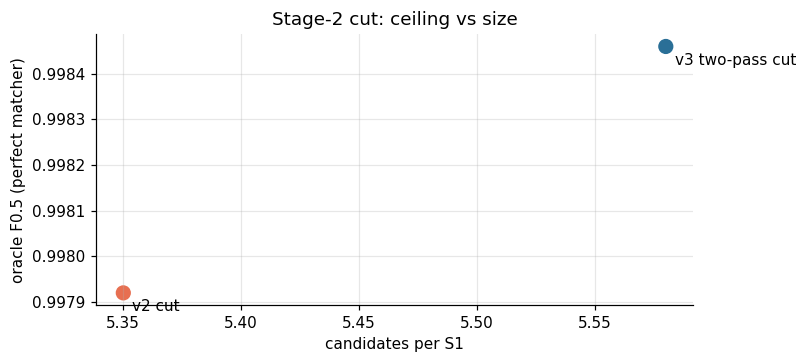

In [9]:
funnel = pl.DataFrame({
    'candidate set (val, 100k S1)': ['sparse keys, top-50', 'dense bi-encoder, top-40', 'union (input to stage 2)', 'v2 stage-2 cut (rank<=8, p>=0.01)', 'v3 two-pass cut (final)'],
    'cand per S1': [49.8, 40.0, 86.7, 5.35, 5.58], 'pair recall': [0.9575, 0.9977, 0.9986, 0.9918, 0.9943],
    'oracle F0.5': [0.98418, 0.99932, 0.99959, 0.99792, 0.99846]})
print(funnel)
lost = pl.DataFrame({'where true val pairs are lost': ['never retrieved', 'cut at stage 2', 'rejected by the matcher', 'found'],
                     'v2 (LB 0.982)': [488, 2346, 6150, 337228], 'final': [488, 1492, 5864, 338368]})
print(lost)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.scatter(funnel['cand per S1'][3:], funnel['oracle F0.5'][3:], s=80, color=[C2, C1])
for x, y, t in zip(funnel['cand per S1'][3:], funnel['oracle F0.5'][3:], ['v2 cut', 'v3 two-pass cut']): ax.annotate(t, (x, y), xytext=(6, -12), textcoords='offset points')
ax.set_xlabel('candidates per S1'); ax.set_ylabel('oracle F0.5 (perfect matcher)'); ax.set_title('Stage-2 cut: ceiling vs size'); plt.show()

**Two-pass stage 2 (`stage2_v3.py`).**
- **Pass 1:** the v2 LightGBM re-ranker scores the ~87 union candidates per S1.
- **Hints from pass 1:**
  - *record-side competition*: the rank and gap of this S1 among **all** S1 claiming the record;
  - *sibling evidence*: does the record's name equal that of a confident record of the same S1;
  - acronym match.
- **Pass 2:** a LightGBM on 200k otherwise unused S1.
- **Cut:** rank ≤ 8 with p ≥ 0.005, or p ≥ 0.15. It recovers 854 of the 2,346 true pairs the v2 cut discarded.

## 5. Feature representation
### 5.1 Feature groups (read from the source code)

In [10]:
KF = {}
def lists(path, names):
    tree = ast.parse(Path(path).read_text(encoding='utf-8')); out = {}
    for node in ast.walk(tree):
        if isinstance(node, ast.Assign) and isinstance(node.targets[0], ast.Name) and node.targets[0].id in names:
            try: out[node.targets[0].id] = ast.literal_eval(node.value)
            except Exception:   # e.g. RR_FEATS = [...] + [f'b_{f}' for f in KEY_FAMILIES] + [...]
                out[node.targets[0].id] = eval(compile(ast.Expression(node.value), path, 'eval'), {'__builtins__': {}}, dict(KF))
    return out
KF.update(lists('er_v2/blocking_sparse.py', ['KEY_FAMILIES']))
L = {**lists('er_v2/stage2.py', ['RR_FEATS', 'S3_FEATS']), **lists('er_v2/features.py', ['FULL_FEATS', 'MULT_FEATS']),
     **lists('er_v2/level1.py', ['COMP_FEATS']), **lists('er_v2/collective.py', ['COLL'])}
desc = {'RR_FEATS': 'stage 2 (cheap): blocking IDF per key family, sparse/dense ranks both directions, dense cosine + gaps, rapidfuzz name/address, ZIP, locality, house number',
        'S3_FEATS': 'stage-2 v3 hints: pass-1 score, record-side rank/gap/count, sibling equality and similarity, acronym, no-address flag',
        'FULL_FEATS': 'full string features: token sort/partial/Levenshtein/prefix/suffix, char n-gram TF-IDF, Jaccard, legal form, script/domain flags, address + number + state agreement',
        'MULT_FEATS': 'multiplicity: how many S1 / records share this name, skeleton or address',
        'COMP_FEATS': 'level-1 competition over the whole candidate graph (S1 side and record side)',
        'COLL': 'collective pass: stacker-score margins, own-vs-rival sibling evidence'}
for k in ['RR_FEATS', 'S3_FEATS', 'FULL_FEATS', 'MULT_FEATS', 'COMP_FEATS', 'COLL']:
    v = L.get(k, [])
    print(f'{k} ({len(v)}): {desc[k]}'); print('   ', ', '.join(v)); print()
print('cross-encoder features: ce (e5-base logit), ce_rank_s, ce_gap_s, ce_n0_s, ce_max_s, ce_rank_r, ce_gap_r, ce_max_other_r, ce_n0_r')
print('LLM feature: qw = Qwen3-Reranker logit(yes) - logit(no) on uncertain pairs (missing elsewhere)')

RR_FEATS (39): stage 2 (cheap): blocking IDF per key family, sparse/dense ranks both directions, dense cosine + gaps, rapidfuzz name/address, ZIP, locality, house number
    bscore, bkeys, brank, b_rel, s_n, r_n, r_rel, r_best, r_gap2, b_t, b_n, b_q, b_p, b_a, b_b, b_z, b_m, b_k, b_c, b_h, n_ratio, n_tset, n_jw, a_tset, a_miss, zip_eq, zip_miss, src3, dcos, drank_s, drank_r, d_gap_s, d_gap_r, r_dn, in_sparse, in_dense, n_sk_eq, loc_jacc, num1_eq

S3_FEATS (13): stage-2 v3 hints: pass-1 score, record-side rank/gap/count, sibling equality and similarity, acronym, no-address flag
    q1, q1_rank_s, q1_gap_s, q1r_rank, q1r_gap, q1r_n05, sib_n, sib_eq_core, sib_eq_sk, sib_tset, acr_eq, acr_pre, r_noaddr

FULL_FEATS (43): full string features: token sort/partial/Levenshtein/prefix/suffix, char n-gram TF-IDF, Jaccard, legal form, script/domain flags, address + number + state agreement
    n_tsort, n_partial, n_lev, n_prefix, n_postfix, n_full_tset, n_tfidf, n_jacc, n_len1, n_len2, n_ntok1, n_

### 5.2 How true pairs separate from hard negatives (live, train sample)

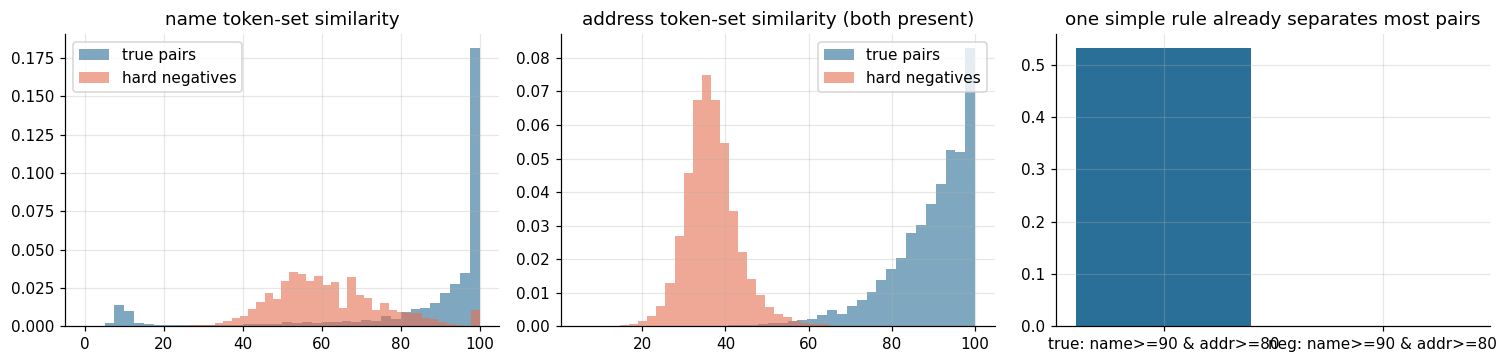

Name alone does not separate (hard negatives share the name); the ADDRESS does -> address-less records are the hard case.


In [11]:
rng = np.random.default_rng(0)
pos = pairs.sample(20000, seed=4).select('country', 'n1', 'a1', 'n2', 'a2').with_columns(y=pl.lit(1))
# hard negatives: an S1 and a record of the same country sharing the first name token, not matched
tok = lambda c: pl.col(c).str.to_lowercase().str.extract(r'([a-z]{3,})', 1)
s = tr1.sample(60000, seed=5).with_columns(t=tok('business_name')).drop_nulls('t')
r = pl.concat([tr2, tr3]).sample(400000, seed=6).with_columns(t=tok('business_name')).drop_nulls('t')
neg = (s.join(r, on=['country', 't'], suffix='_r').filter(pl.col('entity_id') != pl.col('entity_id_r')).sample(40000, seed=7, with_replacement=True)
         .select('country', pl.col('business_name').alias('n1'), pl.col('business_address').alias('a1'),
                 pl.col('business_name_r').alias('n2'), pl.col('business_address_r').alias('a2')).with_columns(y=pl.lit(0)))
d = pl.concat([pos, neg])
L_ = lambda c: d[c].fill_null('').str.to_lowercase().to_list()
d = d.with_columns(name_tset=pl.Series(process.cpdist(L_('n1'), L_('n2'), scorer=fuzz.token_set_ratio, workers=-1)),
                   addr_tset=pl.Series(process.cpdist(L_('a1'), L_('a2'), scorer=fuzz.token_set_ratio, workers=-1)),
                   no_addr=d['a2'].is_null())
fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
for a, col, t in [(ax[0], 'name_tset', 'name token-set similarity'), (ax[1], 'addr_tset', 'address token-set similarity (both present)')]:
    dd = d if col == 'name_tset' else d.filter(~pl.col('no_addr') & pl.col('a1').is_not_null())
    for y, c, lab in [(1, C1, 'true pairs'), (0, C2, 'hard negatives')]:
        a.hist(dd.filter(pl.col('y') == y)[col].to_numpy(), bins=40, alpha=0.6, color=c, label=lab, density=True)
    a.set_title(t); a.legend()
h = d.with_columns(both_high=(pl.col('name_tset') >= 90) & (pl.col('addr_tset') >= 80)).group_by('y').agg(pl.col('both_high').mean(), pl.col('no_addr').mean())
ax[2].bar(['true: name>=90 & addr>=80', 'neg: name>=90 & addr>=80'], h.sort('y', descending=True)['both_high'].to_numpy(), color=[C1, C2])
ax[2].set_title('one simple rule already separates most pairs'); plt.tight_layout(); plt.show()
print('Name alone does not separate (hard negatives share the name); the ADDRESS does -> address-less records are the hard case.')

### 5.3 Which features the models use (LightGBM gain share, from the run logs)

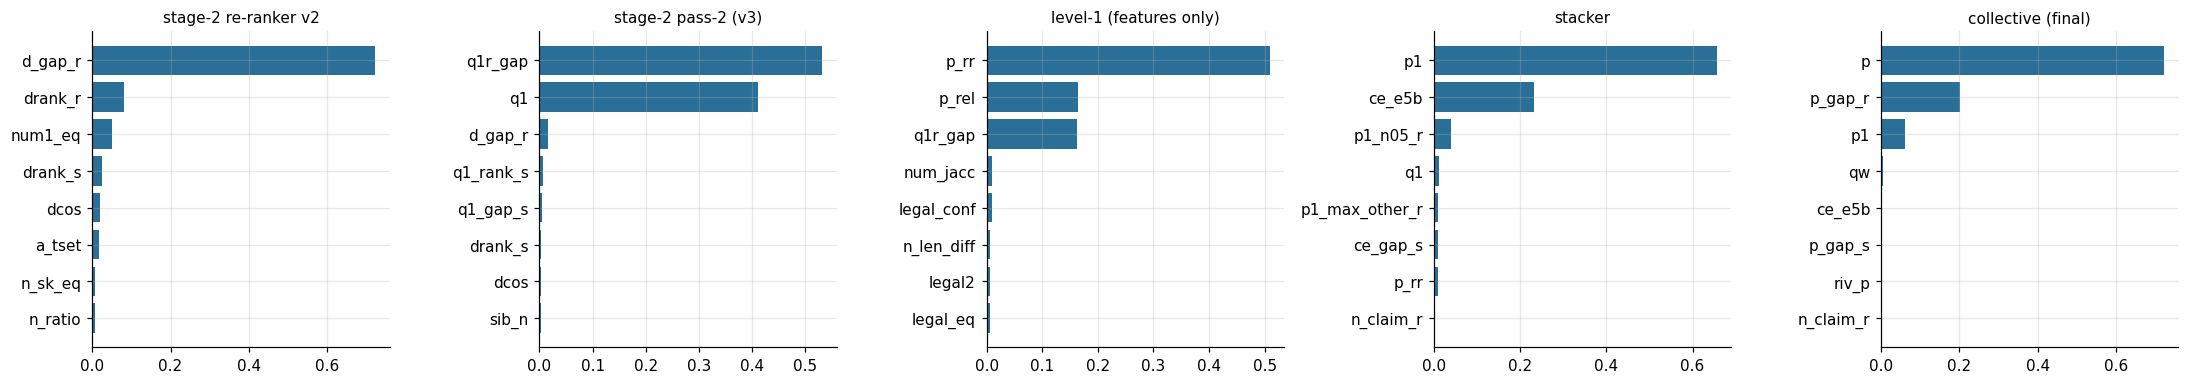

Record-side competition (d_gap_r, q1r_gap, p1_*_r, p_gap_r) is the most used signal at every stage: each record belongs to at most one S1.


In [12]:
imp = {
 'stage-2 re-ranker v2': {'d_gap_r': .724, 'drank_r': .082, 'num1_eq': .051, 'drank_s': .024, 'dcos': .020, 'a_tset': .018, 'n_ratio': .008, 'n_sk_eq': .008},
 'stage-2 pass-2 (v3)': {'q1r_gap': .532, 'q1': .410, 'd_gap_r': .016, 'q1_rank_s': .006, 'q1_gap_s': .004, 'drank_s': .003, 'sib_n': .002, 'dcos': .002},
 'level-1 (features only)': {'p_rr': .509, 'p_rel': .164, 'q1r_gap': .162, 'legal_conf': .010, 'num_jacc': .010, 'legal2': .007, 'n_len_diff': .007, 'legal_eq': .006},
 'stacker': {'p1': .656, 'ce_e5b': .233, 'p1_n05_r': .041, 'q1': .012, 'p1_max_other_r': .011, 'ce_gap_s': .010, 'p_rr': .009, 'n_claim_r': .002},
 'collective (final)': {'p': .721, 'p_gap_r': .202, 'p1': .061, 'qw': .005, 'ce_e5b': .004, 'p_gap_s': .003, 'riv_p': .001, 'n_claim_r': .0005}}
fig, ax = plt.subplots(1, 5, figsize=(20, 3.6))
for a, (k, v) in zip(ax, imp.items()):
    items = sorted(v.items(), key=lambda x: x[1]); a.barh([i[0] for i in items], [i[1] for i in items], color=C1); a.set_title(k, fontsize=10)
plt.tight_layout(); plt.show()
print('Record-side competition (d_gap_r, q1r_gap, p1_*_r, p_gap_r) is the most used signal at every stage: each record belongs to at most one S1.')

## 6. Models and results

shape: (6, 7)
┌────────────────────────────────────────────────────────┬──────────┬──────────┬────────────┬─────────┬─────────┬───────────┐
│ run                                                    ┆ val F0.5 ┆ OOF F0.5 ┆ singletons ┆ macro P ┆ macro R ┆ public LB │
│ ---                                                    ┆ ---      ┆ ---      ┆ ---        ┆ ---     ┆ ---     ┆ ---       │
│ str                                                    ┆ f64      ┆ f64      ┆ f64        ┆ f64     ┆ f64     ┆ str       │
╞════════════════════════════════════════════════════════╪══════════╪══════════╪════════════╪═════════╪═════════╪═══════════╡
│ v2 (baseline)                                          ┆ 0.99013  ┆ 0.98996  ┆ 0.99409    ┆ 0.99739 ┆ 0.97484 ┆ 0.982     │
│ Test 1: two-pass stage 2                               ┆ 0.99053  ┆ 0.9901   ┆ 0.99481    ┆ 0.99768 ┆ 0.97539 ┆ -         │
│ Test 2: + level-1 all rows, CE record-side, collective ┆ 0.99098  ┆ 0.99061  ┆ 0.99517    ┆ 0.99779 ┆ 

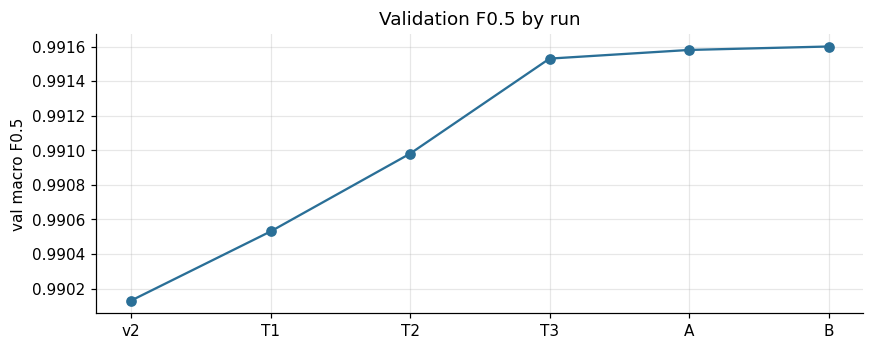

shape: (6, 2)
┌───────────────────────────────────┬──────────┐
│ matcher                           ┆ val F0.5 │
│ ---                               ┆ ---      │
│ str                               ┆ f64      │
╞═══════════════════════════════════╪══════════╡
│ level-1 LightGBM, features only   ┆ 0.98466  │
│ e5-base cross-encoder alone       ┆ 0.98545  │
│ stacker                           ┆ 0.99093  │
│ + collective pass                 ┆ 0.99098  │
│ + Qwen3 score                     ┆ 0.99153  │
│ perfect matcher on our candidates ┆ 0.99846  │
└───────────────────────────────────┴──────────┘


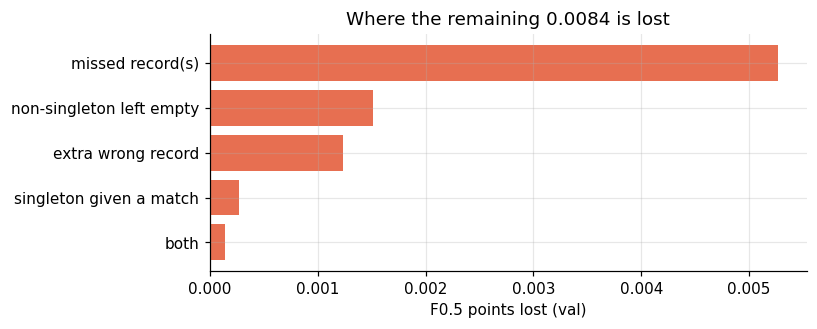

In [13]:
runs = pl.DataFrame({
 'run': ['v2 (baseline)', 'Test 1: two-pass stage 2', 'Test 2: + level-1 all rows, CE record-side, collective', 'Test 3: + Qwen3-Reranker-0.6B',
         'Stage A: + Qwen on wide band', 'Stage B: + Qwen with French-style noise'],
 'val F0.5': [0.99013, 0.99053, 0.99098, 0.99153, 0.99158, 0.99160], 'OOF F0.5': [0.98996, 0.99010, 0.99061, 0.99105, 0.99110, 0.99111],
 'singletons': [0.99409, 0.99481, 0.99517, 0.99499, 0.99517, 0.99463], 'macro P': [0.99739, 0.99768, 0.99779, 0.99798, 0.99803, 0.99800],
 'macro R': [0.97484, 0.97539, 0.97664, 0.97772, 0.97776, 0.97781], 'public LB': ['0.982', '-', '0.9834', '0.986', '-', '-']})
print(runs)
fig, ax = plt.subplots(figsize=(9, 3.3)); ax.plot(range(6), runs['val F0.5'], 'o-', color=C1)
ax.set_xticks(range(6), ['v2', 'T1', 'T2', 'T3', 'A', 'B']); ax.set_ylabel('val macro F0.5'); ax.set_title('Validation F0.5 by run'); plt.show()
abl = pl.DataFrame({'matcher': ['level-1 LightGBM, features only', 'e5-base cross-encoder alone', 'stacker', '+ collective pass', '+ Qwen3 score', 'perfect matcher on our candidates'],
                    'val F0.5': [0.98466, 0.98545, 0.99093, 0.99098, 0.99153, 0.99846]})
print(abl)
loss = {'missed record(s)': 0.00527, 'non-singleton left empty': 0.00151, 'extra wrong record': 0.00123, 'singleton given a match': 0.00027, 'both': 0.00014}
fig, ax = plt.subplots(figsize=(7, 2.8)); ax.barh(list(loss)[::-1], list(loss.values())[::-1], color=C2); ax.set_xlabel('F0.5 points lost (val)')
ax.set_title('Where the remaining 0.0084 is lost'); plt.show()

**Models (all MIT / Apache-2.0, ≤ 0.6B parameters):**

| model | licence | parameters | use |
|---|---|---|---|
| `multilingual-e5-small` | MIT | 118M | bi-encoder |
| `multilingual-e5-base` | MIT | 278M | cross-encoder |
| `Qwen3-Reranker-0.6B` | Apache-2.0 | 596M | fine-tuned 1 epoch on 400k hard pairs; scores uncertain pairs only |
| LightGBM | MIT | – | re-rankers, level-1, stacker, collective pass |

**Decision:** global exclusive assignment (each record goes to at most one S1), then p ≥ 0.70, chosen on OOF.

**On test, the Qwen reranker:**
- removed near-miss merges: 89 % of the US pairs it removed differ in house number;
- added French acronym and DBA matches: France acronym records matched rose from 72 % to 84 %;
- +0.0026 on the leaderboard.

## 7. Why we abstain on address-less, same-name records

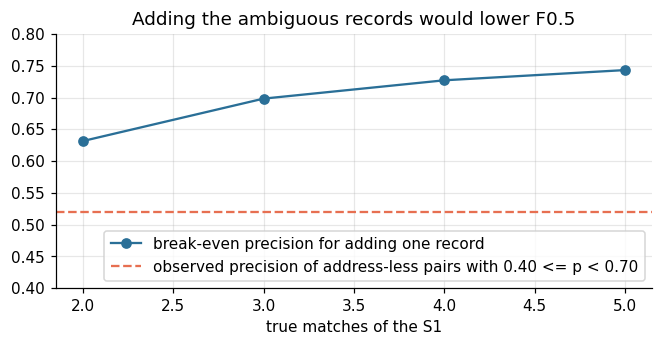

break-even precision: {2: np.float64(0.632), 3: np.float64(0.698), 4: np.float64(0.727), 5: np.float64(0.743)} | a wrong record on a true singleton costs 1.0
97.4 % of S1 predicted empty are true singletons -> "never leave an S1 empty" rules hurt.
Tested and rejected (no separating signal): country, records per source, file order/ids, raw spelling (identical in 57.5 %),
sibling records (17 % helpful vs 8 % misleading), a separate lower threshold for address-less records (F0.5 dropped).


In [14]:
f05 = lambda P, R: 0 if P == 0 or R == 0 else 1.25 * P * R / (0.25 * P + R)
ns = [2, 3, 4, 5]; be = []
for n in ns:
    gain = 1 - f05(1, (n - 1) / n); lossw = 1 - f05(n / (n + 1), 1); be.append(lossw / (gain + lossw))
fig, ax = plt.subplots(figsize=(7, 3)); ax.plot(ns, be, 'o-', color=C1, label='break-even precision for adding one record')
ax.axhline(0.52, color=C2, ls='--', label='observed precision of address-less pairs with 0.40 <= p < 0.70')
ax.set_xlabel('true matches of the S1'); ax.set_ylim(0.4, 0.8); ax.legend(loc='lower right'); ax.set_title('Adding the ambiguous records would lower F0.5'); plt.show()
print('break-even precision:', dict(zip(ns, np.round(be, 3))), '| a wrong record on a true singleton costs 1.0')
print('97.4 % of S1 predicted empty are true singletons -> "never leave an S1 empty" rules hurt.')
print('Tested and rejected (no separating signal): country, records per source, file order/ids, raw spelling (identical in 57.5 %),')
print('sibling records (17 % helpful vs 8 % misleading), a separate lower threshold for address-less records (F0.5 dropped).')

## 8. Pipeline code (full v3 source of the new stages)

In [15]:
print(Path('er_v2/stage2_v3.py').read_text(encoding='utf-8'))

"""Step 3c v3: two-pass stage-2 re-ranker and a recall-oriented cut (run with ER_STAGE2=s3).

v2 kept rank <= 8 and p_rr >= 0.01 per S1. On val that cut drops ~2,350 true pairs, mostly address-less records whose
name several S1 share (their dense margin d_gap_r is ~0, so p_rr is low for every claimant) and records of S1 with
more than 8 true matches. v3:
  pass 1  the v2 re-ranker (stage2_lgb_s2a) scores every union pair -> q1                  (cached per S1 chunk)
  hints   from q1: record-side competition over ALL S1 (q1r_*), sibling evidence (does the record's name_core /
          skeleton equal that of a confident record of the same S1, best name similarity to them), acronym match
  pass 2  a new LightGBM on the v2 features + hints, fitted on 200k S1 of the unused `rest` subset (q1 is
          out-of-sample there), early-stopped on 50k other `rest` S1                          -> p_rr
  cut     keep (rank <= kmax & p >= floor) | p >= p_hi | (S1 among the record's top-R claimants &

In [16]:
print(Path('er_v2/qwen_ce.py').read_text(encoding='utf-8'))

"""Test 3: Qwen3-Reranker-0.6B (Apache-2.0, 0.6B params) fine-tuned as a second cross-encoder, used on uncertain pairs.

Why: e5-base cannot resolve acronyms ("FBP" = "Fun Boutique Primaire SAS"), French abbreviations / region names or
coined DBA names well, and those dominate the test-only (France) loss. A multilingual LLM reranker brings that
pretrained knowledge; the address-less same-name cases stay unresolvable (no signal in the text).
Model: Qwen3ForCausalLM; score = logit('yes') - logit('no') at the last position of the official reranker prompt
(left padding; only the last hidden state goes through the LM head). Fine-tuned 1 epoch with BCE on hard stage-2
candidates of `ce_train` S1 that are NOT in the evaluation set (so eval / test scores are out-of-sample).
Scored only where the Test-1 stacker is uncertain (UNC_LO <= p <= UNC_HI); elsewhere the feature is missing.

    python -m er_v2.qwen_ce train      # ~20-40 min on the A100
    python -m er_v2.qwen_ce score      # eval + t

In [17]:
print(Path('er_v2/collective.py').read_text(encoding='utf-8'))

"""Test 2, step 3: collective second pass over the stacker's predictions ("resolve the easy records, then use them").

After the stacker, ~91 % of S1 are already perfect. Their confident records (p >= CORE_T and the S1 is the record's
top claimant) are trusted evidence for the doubtful ones. For each candidate pair (s, r):
  own   : sib_n (confident records of s), sib_eq_core / sib_eq_sk / sib_eq_raw (how many share r's normalised name,
          phonetic skeleton, raw lower-cased name), sib_tset (best name similarity to them), sib_addr (best address
          similarity to them, -1 if r has no address)
  rival : the same features for r's best OTHER claimant, and own - rival differences
  graph : rank / gap / count of the pair among the record's claimants and the S1's candidates (on p)
A second LightGBM on p, CE, p1 and these features is fitted 5-fold (GroupKFold by S1) on stack_train; val is only
reported. p on stack_train rows is the stacker's OOF p, so no row is scored by a model th

In [18]:
print(Path('er_v2/write_final.py').read_text(encoding='utf-8'))

"""Writes the final submission from the collective model's test probabilities (the last step of the pipeline).

Decision (chosen on stack_train OOF, reported on val): global exclusive assignment (each S2/S3 record is kept only for
its highest-scoring S1), then keep pairs with p >= threshold. The candidate file is the stage-2 v3 candidate set.

    ER_STAGE2=s3 ER_FEAT=f3 python -m er_v2.write_final test_p_f3br_qw_coll_e5b.parquet 0.70 <out_dir>
    (Test 3 / leaderboard 0.986: test_p_f3br_qw_coll_e5b.parquet, threshold 0.70)
"""
import sys
from pathlib import Path
import polars as pl
from .config import OUT, log
from .metrics import exclusive
from .stage2 import stage2_path


def main(test_p, t, out_dir):
    from . import stack
    stack.FINAL_OUT = Path(out_dir); stack.FINAL_OUT.mkdir(parents=True, exist_ok=True)
    d = pl.read_parquet(OUT / test_p).select('i1', 'ir', 'p')
    pred = exclusive(d).filter(pl.col('p') >= t).select('i1', 'ir')
    log(f'{test_p}: {pred.height:,} matched

The other stages are in the same folder: `normalize`, `splits`, `blocking_sparse`, `dense`, `stage2`, `features`, `level1`, `cross_encoder`, `stack`, `metrics`, `summary`, `diag_recall`. `README.md` gives the full order.

## 9. Reproduce
The full run needs a CUDA GPU (bf16) and about 4 h; set `RUN_PIPELINE = True` on such a machine (data paths via `ER_DATA_DIR` / `ER_ROOT`).

In [19]:
RUN_PIPELINE = False
STEPS = '''python -m er_v2.normalize && python -m er_v2.splits && python -m er_v2.blocking_sparse && python -m er_v2.dense && python -m er_v2.stage2
ER_STAGE2=s3 ER_FEAT=f3 python -m er_v2.run_test1
ER_STAGE2=s3 ER_FEAT=f3 ER_L1=b ER_STACK=r python -m er_v2.run_test2
ER_STAGE2=s3 ER_FEAT=f3 python -m er_v2.qwen_ce train
ER_STAGE2=s3 ER_FEAT=f3 python -m er_v2.qwen_ce score
ER_STAGE2=s3 ER_FEAT=f3 ER_QW_BAND=0.02,0.98 ER_QW_MODEL=qwen_rr06 ER_QW_OUT=_wide ER_QW_REUSE= python -m er_v2.qwen_ce score
ER_STAGE2=s3 ER_FEAT=f3 ER_L1=b ER_STACK=r ER_QW=1 ER_QW_FILES=_wide:qw ER_QW_TAG=_qwA ER_RULE=global python -m er_v2.collective
ER_STAGE2=s3 ER_FEAT=f3 python -m er_v2.write_final test_p_f3br_qwA_coll_e5b.parquet 0.70 $ER_ROOT/../output'''
print(STEPS)
if RUN_PIPELINE:
    for line in STEPS.splitlines():
        subprocess.run(line, shell=True, check=True)

python -m er_v2.normalize && python -m er_v2.splits && python -m er_v2.blocking_sparse && python -m er_v2.dense && python -m er_v2.stage2
ER_STAGE2=s3 ER_FEAT=f3 python -m er_v2.run_test1
ER_STAGE2=s3 ER_FEAT=f3 ER_L1=b ER_STACK=r python -m er_v2.run_test2
ER_STAGE2=s3 ER_FEAT=f3 python -m er_v2.qwen_ce train
ER_STAGE2=s3 ER_FEAT=f3 python -m er_v2.qwen_ce score
ER_STAGE2=s3 ER_FEAT=f3 ER_QW_BAND=0.02,0.98 ER_QW_MODEL=qwen_rr06 ER_QW_OUT=_wide ER_QW_REUSE= python -m er_v2.qwen_ce score
ER_STAGE2=s3 ER_FEAT=f3 ER_L1=b ER_STACK=r ER_QW=1 ER_QW_FILES=_wide:qw ER_QW_TAG=_qwA ER_RULE=global python -m er_v2.collective
ER_STAGE2=s3 ER_FEAT=f3 python -m er_v2.write_final test_p_f3br_qwA_coll_e5b.parquet 0.70 $ER_ROOT/../output


## 10. Official validator on the submitted files

In [20]:
r = subprocess.run([sys.executable, 'submissions/validate_submission.py', '--matching', str(MATCHING), '--candidate', str(CANDIDATE),
                    '--test-dir', str(DATA / 'test'), '--check-ids'], capture_output=True, text=True, encoding='utf-8', errors='replace')
print(r.stdout[-1500:])
m = rd(MATCHING); n = m.with_columns(k=pl.when(pl.col('matched_entity_ids').fill_null('') == '').then(0)
                                        .otherwise(pl.col('matched_entity_ids').str.count_matches(',') + 1))
print(n.join(te1.select(pl.col('entity_id').alias('source1_entity_id'), 'country'), on='source1_entity_id')
       .group_by('country').agg(pl.col('k').mean().round(3).alias('pred per S1'), (pl.col('k') == 0).mean().round(4).alias('empty share')).sort('country'))

ML Challenge 2026 � submission validator
  test dir: C:\Users\hrutu\OneDrive\Desktop\Amazon_Challenge\Amazon_Challenge\data\test
  required S1 entities: 1732544
  valid S2/S3 match IDs: 9969589
  matching_results.tsv: 1732544 rows (100129 empty, 1632415 non-empty).
  candidate_pairs.tsv: 1732544 rows (5354 empty, 1727190 non-empty).

PASS � no blocking issues found. Safe to submit.



shape: (3, 3)
┌─────────┬─────────────┬─────────────┐
│ country ┆ pred per S1 ┆ empty share │
│ ---     ┆ ---         ┆ ---         │
│ str     ┆ f64         ┆ f64         │
╞═════════╪═════════════╪═════════════╡
│ France  ┆ 3.321       ┆ 0.0575      │
│ India   ┆ 3.39        ┆ 0.0576      │
│ US      ┆ 3.385       ┆ 0.0582      │
└─────────┴─────────────┴─────────────┘
